In [4]:
# =============================================================================
# 1. MONTAR O GOOGLE DRIVE
# =============================================================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
#importando a tabela de regiões

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Produtividade/reg_latlongofc.csv")

# corrigir decimal
df["lat"] = df["lat"].astype(str).str.replace(",", ".").astype(float)
df["long"] = df["long"].astype(str).str.replace(",", ".").astype(float)

# padronizar nomes das regiões
df["REGIAO"] = (
    df["REGIAO"]
    .str.replace("-", "")
    .str.replace(" ", "")
)

In [6]:
#Criando um dicionário

coords_regioes = (
    df
    .groupby("REGIAO")
    .agg(
        lat=("lat", "mean"),
        lon=("long", "mean"),
        n_municipios=("Nome_3","count")
    )
    .reset_index()
)

print(coords_regioes)

       REGIAO        lat        lon  n_municipios
0   CentroSul -15.186100 -56.703288            23
1  MedioNorte -12.556416 -55.624070            17
2    Nordeste -12.118473 -51.962693            22
3    Noroeste -10.836789 -58.545893            12
4       Norte -10.177389 -55.668920            17
5       Oeste -14.948722 -58.712278            22
6     Sudeste -15.957210 -53.823512            29


In [7]:
coords = {
    "CentroSul": {"lat": -15.186100, "lon": -56.703288},
    "MedioNorte": {"lat": -12.556416, "lon": -55.624070},
    "Nordeste": {"lat": -12.118473, "lon": -51.962693},
    "Noroeste": {"lat": -10.836789, "lon": -58.545893},
    "Norte": {"lat": -10.177389, "lon": -55.668920},
    "Oeste": {"lat": -14.948722, "lon": -58.712278},
    "Sudeste": {"lat": -15.957210, "lon": -53.823512}
}

In [8]:
#Transformando para usar no script
coords = {
    row["REGIAO"]: {"lat": row["lat"], "lon": row["lon"]}
    for _, row in coords_regioes.iterrows()
}

In [9]:
#identificar a safra

def identificar_safra(data):
    ano = data.year
    if data.month >= 9:
        return f"{ano}/{ano+1}"
    else:
        return f"{ano-1}/{ano}"

In [10]:
#Baixar od dados nasa power

import requests
import pandas as pd

def get_nasa_power_full(lat, lon):

    url = "https://power.larc.nasa.gov/api/temporal/daily/point"

    params = {
        "parameters": "PRECTOTCORR,T2M,ALLSKY_SFC_SW_DWN",
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": "20070901",
        "end": "20260331",
        "format": "JSON"
    }

    try:

        response = requests.get(url, params=params, timeout=30)

        if response.status_code != 200:
            print("Erro HTTP:", response.status_code)
            return None

        data = response.json()

        if "properties" not in data:
            print("Erro na resposta da API")
            return None

        df = pd.DataFrame(data["properties"]["parameter"])
        df = df.apply(pd.to_numeric, errors="coerce")

        df.index = pd.to_datetime(df.index)

        df = df.rename(columns={
            "PRECTOTCORR": "precip",
            "T2M": "temp",
            "ALLSKY_SFC_SW_DWN": "rad"
        })

        return df

    except Exception as e:

        print("Erro na requisição:", e)
        return None

In [11]:
#séries diárias

def calcular_variaveis_safra(df):

    df = df.copy()

    df["Safra"] = df.index.map(identificar_safra)

    clima_safra = (
        df.groupby("Safra")
        .agg(
            precip_total=("precip", "sum"),
            temp_media=("temp", "mean"),
            rad_media=("rad", "mean")
        )
        .reset_index()
    )

    return clima_safra

In [12]:
#Clima para todas as regiões

clima_regioes = []

for regiao in coords:

    lat = coords[regiao]["lat"]
    lon = coords[regiao]["lon"]

    df_clima = get_nasa_power_full(lat, lon)

    if df_clima is None:
        continue

    df_safra = calcular_variaveis_safra(df_clima)

    df_safra["Regiao"] = regiao

    clima_regioes.append(df_safra)

In [13]:
#Unir todas as regiões

clima_final = pd.concat(clima_regioes)
clima_final = clima_final.reset_index(drop=True)
print(clima_final.head())

       Safra  precip_total  temp_media  rad_media     Regiao
0  2007/2008       1597.36   25.844891  18.619863  CentroSul
1  2008/2009       1330.20   26.359616  19.327890  CentroSul
2  2009/2010       1650.28   25.869644  19.027534  CentroSul
3  2010/2011       1594.56   25.650877  18.824219  CentroSul
4  2011/2012       1270.36   26.266230  19.838333  CentroSul


In [14]:
#Chamando a produtividade
df = pd.read_csv("/content/drive/MyDrive/Produtividade/Produtividade.csv")

In [15]:
df.head()
df.columns

Index(['safras', 'PlantioInicio', 'Plantiofim', 'CentroSul', 'MedioNorte',
       'Nordeste', 'Noroeste', 'Norte', 'Oeste', 'Sudeste', 'ONI'],
      dtype='object')

In [16]:
clima_final["Regiao"].unique()

array(['CentroSul', 'MedioNorte', 'Nordeste', 'Noroeste', 'Norte',
       'Oeste', 'Sudeste'], dtype=object)

In [17]:
clima_final["Safra"].head()

,Safra
0,2007/2008
1,2008/2009
2,2009/2010
3,2010/2011
4,2011/2012


In [18]:
#produtividade para formato longo

df_long = df.melt(
    id_vars=["safras", "PlantioInicio", "Plantiofim", "ONI"],
    value_vars=[
        "CentroSul",
        "MedioNorte",
        "Nordeste",
        "Noroeste",
        "Norte",
        "Oeste",
        "Sudeste"
    ],
    var_name="Regiao",
    value_name="Produtividade"
)

In [19]:
df_long.head()

,safras,PlantioInicio,Plantiofim,ONI,Regiao,Produtividade
0,2007/2008,NaN,NaN,NaN,CentroSul,3.009
1,2008/2009,17/09,11/12,NaN,CentroSul,2.919
2,2009/2010,24/09,10/12,NaN,CentroSul,2.958
3,2010/2011,30/09,02/12,NaN,CentroSul,3.161
4,2011/2012,29/09,01/12,NaN,CentroSul,3.081


In [20]:
#Mudando so o Inicial Safra era safra

df_long = df_long.rename(columns={"safras": "Safra"})

In [21]:
#conferindo as colunas

df_long.columns

Index(['Safra', 'PlantioInicio', 'Plantiofim', 'ONI', 'Regiao',
       'Produtividade'],
      dtype='object')

In [22]:
#juntar produtividade + clima

dataset = df_long.merge(
    clima_final,
    on=["Safra", "Regiao"],
    how="left"
)

In [23]:
#Deu certo?
dataset.head()

,Safra,PlantioInicio,Plantiofim,ONI,Regiao,Produtividade,precip_total,temp_media,rad_media
0,2007/2008,NaN,NaN,NaN,CentroSul,3.009,1597.36,25.844891,18.619863
1,2008/2009,17/09,11/12,NaN,CentroSul,2.919,1330.20,26.359616,19.327890
2,2009/2010,24/09,10/12,NaN,CentroSul,2.958,1650.28,25.869644,19.027534
3,2010/2011,30/09,02/12,NaN,CentroSul,3.161,1594.56,25.650877,18.824219
4,2011/2012,29/09,01/12,NaN,CentroSul,3.081,1270.36,26.266230,19.838333


In [24]:
#Salvar no drive

#Baixar a tabela no drive

dataset.to_csv(
    "/content/drive/MyDrive/Produtividade/dataset_soja_clima_mt09_03.csv",
    index=False
)


#===========================================================
from google.colab import files
dataset.to_csv("dataset_soja_clima_mt.csv", index=False)
files.download("dataset_soja_clima_mt.csv")
#BAIXAR NO COMPUTADOR
#============================================================

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
#Correlação simples

dataset[[
"Produtividade",
"precip_total",
"temp_media",
"rad_media",
"ONI"
]].corr()

,Produtividade,precip_total,temp_media,rad_media,ONI
Produtividade,1.000000,-0.398413,0.318508,0.111007,-0.316503
precip_total,-0.398413,1.000000,-0.508642,-0.186001,-0.281795
temp_media,0.318508,-0.508642,1.000000,0.476080,0.409859
rad_media,0.111007,-0.186001,0.476080,1.000000,0.310738
ONI,-0.316503,-0.281795,0.409859,0.310738,1.000000


In [26]:
#A variável que está explicando a produtividade é a tendência tecnológica

dataset["ano"] = dataset["Safra"].str[:4].astype(int)
dataset[["Produtividade","ano"]].corr()

,Produtividade,ano
Produtividade,1.000000,0.870441
ano,0.870441,1.000000


In [27]:
#calcular a janela de plantio

dataset["PlantioInicio_dt"] = pd.to_datetime(
    dataset["PlantioInicio"],
    format="%d/%m",
    errors="coerce"
)

dataset["Plantiofim_dt"] = pd.to_datetime(
    dataset["Plantiofim"],
    format="%d/%m",
    errors="coerce"
)

In [28]:
#Fazendo o Pandas ler as datas

dataset[["PlantioInicio","PlantioInicio_dt","Plantiofim","Plantiofim_dt"]].head()

,PlantioInicio,PlantioInicio_dt,Plantiofim,Plantiofim_dt
0,NaN,NaT,NaN,NaT
1,17/09,1900-09-17,11/12,1900-12-11
2,24/09,1900-09-24,10/12,1900-12-10
3,30/09,1900-09-30,02/12,1900-12-02
4,29/09,1900-09-29,01/12,1900-12-01


In [29]:
# calcular a janela de plantio (dias)
dataset["janela_plantio"] = (
    dataset["Plantiofim_dt"] - dataset["PlantioInicio_dt"]
).dt.days

# corrigir casos que atravessam o ano (ex.: termina em janeiro)
dataset.loc[dataset["janela_plantio"] < 0, "janela_plantio"] += 365

In [30]:
dataset[["Safra","PlantioInicio","Plantiofim","janela_plantio"]].head()

,Safra,PlantioInicio,Plantiofim,janela_plantio
0,2007/2008,NaN,NaN,NaN
1,2008/2009,17/09,11/12,85.0
2,2009/2010,24/09,10/12,77.0
3,2010/2011,30/09,02/12,63.0
4,2011/2012,29/09,01/12,63.0


In [31]:
#verificar se todas as variáveis do modelo estão numéricas

dataset[[
"Produtividade",
"ano",
"precip_total",
"temp_media",
"rad_media",
"ONI",
"janela_plantio"
]].dtypes

,0
Produtividade,float64
ano,int64
precip_total,float64
temp_media,float64
rad_media,float64
ONI,float64
janela_plantio,float64


In [32]:
#filtre apenas as colunas necessárias e remova linhas com valores ausentes nas variáveis usadas no modelo
cols = ["Produtividade", "ano", "precip_total", "ONI", "janela_plantio"]
df_model = dataset[cols].dropna()
df_model.shape

(91, 5)

In [33]:
# separe variáveis explicativas e variável resposta
X = df_model[["ano", "precip_total", "ONI", "janela_plantio"]]
y = df_model["Produtividade"]

Produtividade =
β₀ + β₁·ano + β₂·precip_total + β₃·ONI + β₄·janela_plantio

β₀ → intercepto

β₁ → ganho tecnológico anual

β₂ → efeito da precipitação

β₃ → efeito do ENSO (ONI)

β₄ → efeito da janela de plantio

In [34]:
#Ajuste o modelo

from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [35]:
#coeficientes estimados
import pandas as pd

coef = pd.Series(modelo.coef_, index=X.columns)
print(coef)
print("Intercepto:", modelo.intercept_)

ano               0.049242
precip_total      0.000007
ONI              -0.011524
janela_plantio   -0.003901
dtype: float64
Intercepto: -95.73278029096114


In [36]:
#Detrending
#técnica usada em estudos agrícolas
#que melhora bastante a análise climática da produtividade.
#Ela separa tecnologia de clima.

from sklearn.linear_model import LinearRegression

X_trend = dataset[["ano"]]
y_trend = dataset["Produtividade"]

modelo_trend = LinearRegression()
modelo_trend.fit(X_trend, y_trend)

dataset["trend_prod"] = modelo_trend.predict(X_trend)

In [37]:
#Produtividade por tendência

dataset["prod_detrended"] = dataset["Produtividade"] - dataset["trend_prod"]

In [38]:
#trend_prod = produtividade esperada apenas pelo avanço tecnológico
#prod_detrended = desvio causado principalmente pelo clima


dataset[[
"Safra",
"Produtividade",
"trend_prod",
"prod_detrended"
]].head()

,Safra,Produtividade,trend_prod,prod_detrended
0,2007/2008,3.009,2.881988,0.127012
1,2008/2009,2.919,2.926955,-0.007955
2,2009/2010,2.958,2.971922,-0.013922
3,2010/2011,3.161,3.016889,0.144111
4,2011/2012,3.081,3.061856,0.019144


In [39]:
#clima se relaciona com essa produtividade detrended????

dataset[[
"prod_detrended",
"precip_total",
"temp_media",
"rad_media",
"ONI",
"janela_plantio"
]].corr()

,prod_detrended,precip_total,temp_media,rad_media,ONI,janela_plantio
prod_detrended,1.000000,0.083189,-0.306593,-0.100522,-0.400201,-0.409875
precip_total,0.083189,1.000000,-0.508642,-0.186001,-0.281795,-0.166821
temp_media,-0.306593,-0.508642,1.000000,0.476080,0.409859,0.226113
rad_media,-0.100522,-0.186001,0.476080,1.000000,0.310738,0.150476
ONI,-0.400201,-0.281795,0.409859,0.310738,1.000000,0.800176
janela_plantio,-0.409875,-0.166821,0.226113,0.150476,0.800176,1.000000


In [40]:
#análises por região
for r in dataset["Regiao"].unique():

    sub = dataset[dataset["Regiao"] == r]

    corr = sub[[
        "prod_detrended",
        "precip_total",
        "temp_media",
        "rad_media",
        "ONI",
        "janela_plantio"
    ]].corr()["prod_detrended"]

    print("\n======================")
    print("Região:", r)
    print("======================")
    print(corr)



Região: CentroSul
prod_detrended    1.000000
precip_total      0.259104
temp_media       -0.398712
rad_media         0.112145
ONI              -0.472499
janela_plantio   -0.392453
Name: prod_detrended, dtype: float64

Região: MedioNorte
prod_detrended    1.000000
precip_total      0.527188
temp_media       -0.660510
rad_media        -0.216538
ONI              -0.402665
janela_plantio   -0.346425
Name: prod_detrended, dtype: float64

Região: Nordeste
prod_detrended    1.000000
precip_total      0.445771
temp_media       -0.562892
rad_media        -0.541233
ONI              -0.630500
janela_plantio   -0.714379
Name: prod_detrended, dtype: float64

Região: Noroeste
prod_detrended    1.000000
precip_total      0.213236
temp_media       -0.310421
rad_media        -0.331789
ONI              -0.480898
janela_plantio   -0.473203
Name: prod_detrended, dtype: float64

Região: Norte
prod_detrended    1.000000
precip_total     -0.234806
temp_media        0.081761
rad_media        -0.024965
ONI   

In [41]:
#Regressoes separadas por região

from sklearn.linear_model import LinearRegression
import pandas as pd

resultados = []

for r in dataset["Regiao"].unique():

    sub = dataset[dataset["Regiao"] == r]

    cols = ["Produtividade", "ano", "precip_total", "ONI", "janela_plantio"]
    sub = sub[cols].dropna()

    X = sub[["ano", "precip_total", "ONI", "janela_plantio"]]
    y = sub["Produtividade"]

    modelo = LinearRegression()
    modelo.fit(X, y)

    resultados.append({
        "Regiao": r,
        "coef_ano": modelo.coef_[0],
        "coef_precip": modelo.coef_[1],
        "coef_ONI": modelo.coef_[2],
        "coef_janela": modelo.coef_[3],
        "intercepto": modelo.intercept_
    })

resultados_df = pd.DataFrame(resultados)

resultados_df

,Regiao,coef_ano,coef_precip,coef_ONI,coef_janela,intercepto
0,CentroSul,0.047082,-0.000038,-0.053354,0.000546,-91.682840
1,MedioNorte,0.041599,0.000122,-0.012202,-0.003113,-80.519453
2,Nordeste,0.047001,-0.000205,-0.009350,-0.011020,-90.469645
3,Noroeste,0.074612,0.000324,-0.041920,0.003493,-147.921183
4,Norte,0.061049,0.000056,0.004706,-0.005114,-119.536671
5,Oeste,0.052928,0.000047,0.016040,-0.000663,-103.404243
6,Sudeste,0.071858,0.000319,-0.019579,0.000383,-142.032217


Calcular a projeção baseada na nossa equação de regressão Produtividade =
intercepto + coef_ano·ano + coef_precip·precip_total + coef_ONI·ONI + coef_janela·janela_plantio

In [42]:
#calcular essas médias por região
medias_regiao = dataset.groupby("Regiao")[[
    "precip_total",
    "janela_plantio"
]].mean().reset_index()

medias_regiao

,Regiao,precip_total,janela_plantio
0,CentroSul,1249.757778,72.647059
1,MedioNorte,1412.262778,72.647059
2,Nordeste,1355.848889,72.647059
3,Noroeste,1526.091667,72.647059
4,Norte,1737.089444,72.647059
5,Oeste,1134.298333,72.647059
6,Sudeste,1305.631667,72.647059


In [43]:
# juntar coeficientes com médias climáticas
proj = resultados_df.merge(medias_regiao, on="Regiao")

# definir condições da safra projetada
proj["ano"] = 2025
proj["ONI"] = -0.6

# calcular produtividade projetada
proj["Prod_proj_25_26"] = (
    proj["intercepto"]
    + proj["coef_ano"] * proj["ano"]
    + proj["coef_precip"] * proj["precip_total"]
    + proj["coef_ONI"] * proj["ONI"]
    + proj["coef_janela"] * proj["janela_plantio"]
)

proj[["Regiao","Prod_proj_25_26"]]

#A produtividade estimada pelo modelo climático + tendência tecnológica para a safra 2025/2026.

,Regiao,Prod_proj_25_26
0,CentroSul,3.683052
1,MedioNorte,3.672086
2,Nordeste,3.634966
3,Noroeste,3.942699
4,Norte,3.810376
5,Oeste,3.770798
6,Sudeste,3.936231


CentroSul | desvio padrão resíduos: 0.103


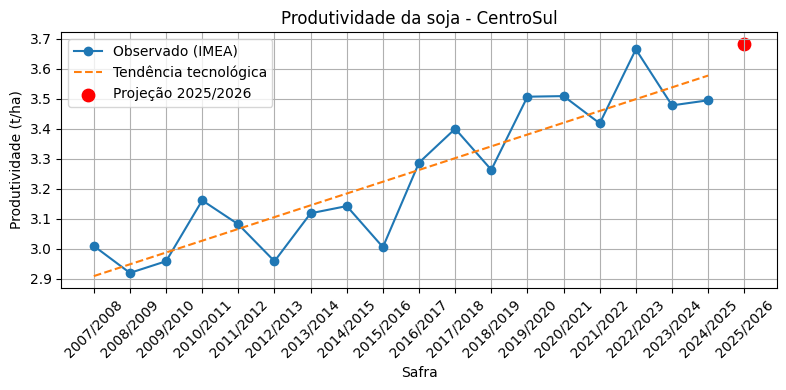

MedioNorte | desvio padrão resíduos: 0.156


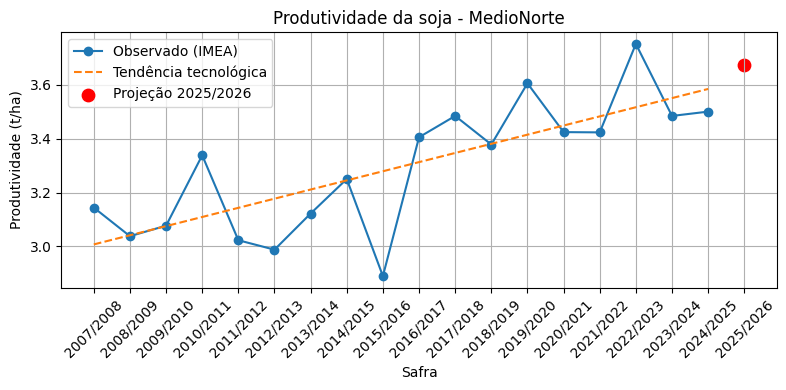

Nordeste | desvio padrão resíduos: 0.151


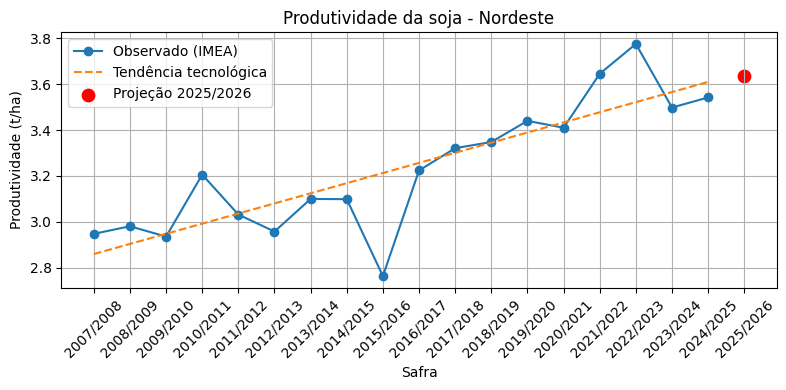

Noroeste | desvio padrão resíduos: 0.106


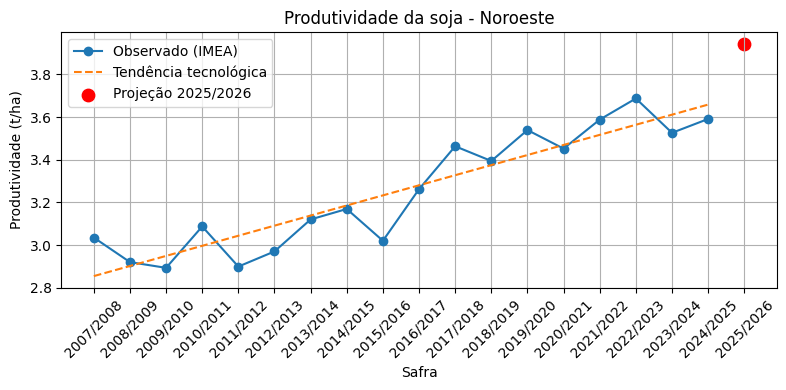

Norte | desvio padrão resíduos: 0.167


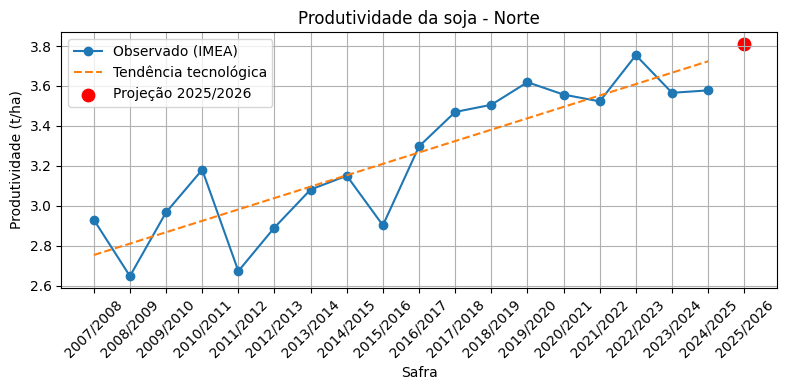

Oeste | desvio padrão resíduos: 0.087


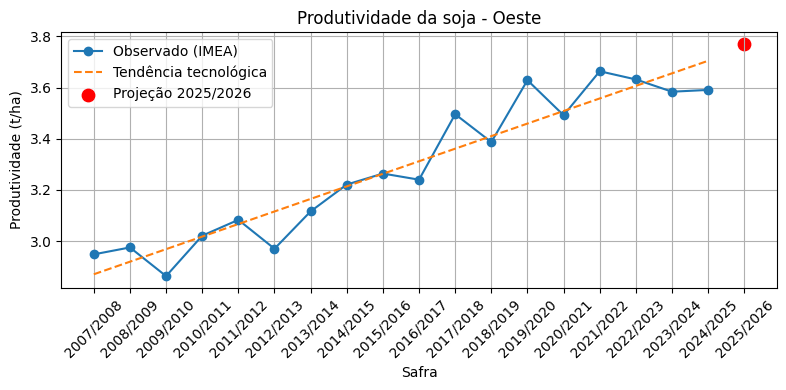

Sudeste | desvio padrão resíduos: 0.104


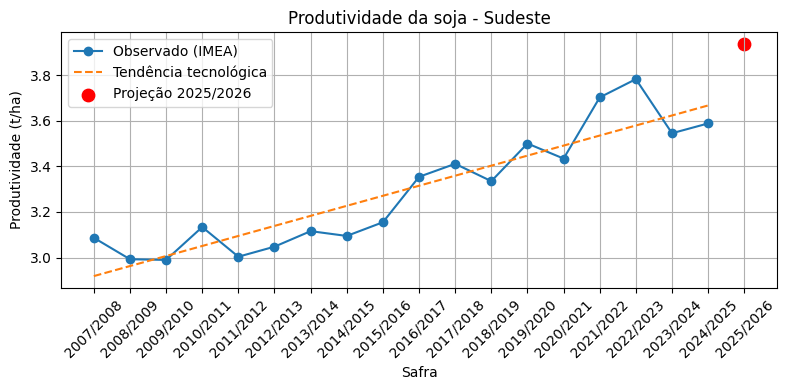

In [44]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Projeção para 2025/2026
ano_proj = 2025
oni_proj = -0.6

janela_media = dataset.groupby("Regiao")["janela_plantio"].mean()
precip_media = dataset.groupby("Regiao")["precip_total"].mean()

for r in dataset["Regiao"].unique():

    sub = dataset[dataset["Regiao"] == r].copy()
    sub = sub.sort_values("ano")

    coef = resultados_df[resultados_df["Regiao"] == r].iloc[0]

    janela = janela_media[r]
    precip = precip_media[r]

    prod_proj = (
        coef["intercepto"]
        + coef["coef_ano"] * ano_proj
        + coef["coef_precip"] * precip
        + coef["coef_ONI"] * oni_proj
        + coef["coef_janela"] * janela
    )

    X = sub[["ano"]]
    y = sub["Produtividade"]

    modelo = LinearRegression()
    modelo.fit(X, y)

    # tendência tecnológica
    sub["trend"] = modelo.predict(X)

    # =========================
    # DESVIO PADRÃO DOS RESÍDUOS
    # =========================

    residuos = y - modelo.predict(X)
    print(f"{r} | desvio padrão resíduos:", round(residuos.std(),3))

    # =========================
    # GRÁFICO
    # =========================

    plt.figure(figsize=(8,4))

    plt.plot(sub["Safra"], sub["Produtividade"],
             marker="o", label="Observado (IMEA)")

    plt.plot(sub["Safra"], sub["trend"],
             linestyle="--", label="Tendência tecnológica")

    plt.scatter("2025/2026", prod_proj,
                color="red", s=80, label="Projeção 2025/2026")

    plt.title(f"Produtividade da soja - {r}")
    plt.xlabel("Safra")
    plt.ylabel("Produtividade (t/ha)")

    plt.xticks(rotation=45)

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [45]:
tabela_grafico = []

ano_proj = 2025
oni_proj = -0.6

janela_media = dataset.groupby("Regiao")["janela_plantio"].mean()
precip_media = dataset.groupby("Regiao")["precip_total"].mean()

for r in dataset["Regiao"].unique():

    sub = dataset[dataset["Regiao"] == r].copy()
    sub = sub.sort_values("ano")

    coef = resultados_df[resultados_df["Regiao"] == r].iloc[0]

    janela = janela_media[r]
    precip = precip_media[r]

    prod_proj = (
        coef["intercepto"]
        + coef["coef_ano"] * ano_proj
        + coef["coef_precip"] * precip
        + coef["coef_ONI"] * oni_proj
        + coef["coef_janela"] * janela
    )

    tabela_grafico.append({
        "Regiao": r,
        "coef_ano": coef["coef_ano"],
        "coef_ONI": coef["coef_ONI"],
        "coef_janela": coef["coef_janela"],
        "Prod_proj_25_26": prod_proj
    })

tabela_grafico = pd.DataFrame(tabela_grafico)

tabela_grafico

,Regiao,coef_ano,coef_ONI,coef_janela,Prod_proj_25_26
0,CentroSul,0.047082,-0.053354,0.000546,3.683052
1,MedioNorte,0.041599,-0.012202,-0.003113,3.672086
2,Nordeste,0.047001,-0.009350,-0.011020,3.634966
3,Noroeste,0.074612,-0.041920,0.003493,3.942699
4,Norte,0.061049,0.004706,-0.005114,3.810376
5,Oeste,0.052928,0.016040,-0.000663,3.770798
6,Sudeste,0.071858,-0.019579,0.000383,3.936231


In [46]:
#tabela do gráfico
tabela_grafico.to_csv(
"/content/drive/MyDrive/Produtividade/projecao0903_produtividade_2526.csv",
index=False
)

In [47]:
#Dados IMEA
imea = pd.DataFrame({
"Safra":[
"2024/2025","2025/2026",
"2024/2025","2025/2026",
"2024/2025","2025/2026",
"2024/2025","2025/2026",
"2024/2025","2025/2026",
"2024/2025","2025/2026",
"2024/2025","2025/2026"
],
"Regiao":[
"CentroSul","CentroSul",
"MedioNorte","MedioNorte",
"Nordeste","Nordeste",
"Noroeste","Noroeste",
"Norte","Norte",
"Oeste","Oeste",
"Sudeste","Sudeste"
],
"Produtividade":[
3.834,3.839,
4.131,4.023,
3.822,3.860,
4.124,3.818,
4.007,3.825,
4.089,3.995,
3.826,3.700
]
})

In [48]:
#ados do IMEA em duas colunas (24/25 e 25/26) para juntar com a projeção do seu modelo.
# separar produtividade IMEA por safra
obs_2425 = imea[imea["Safra"] == "2024/2025"][["Regiao","Produtividade"]]
obs_2526 = imea[imea["Safra"] == "2025/2026"][["Regiao","Produtividade"]]

obs_2425 = obs_2425.rename(columns={"Produtividade":"Prod_obs_24_25"})
obs_2526 = obs_2526.rename(columns={"Produtividade":"Prod_obs_25_26"})


In [49]:
tabela_final = tabela_grafico.merge(obs_2425, on="Regiao")
tabela_final = tabela_final.merge(obs_2526, on="Regiao")

tabela_final

,Regiao,coef_ano,coef_ONI,coef_janela,Prod_proj_25_26,Prod_obs_24_25,Prod_obs_25_26
0,CentroSul,0.047082,-0.053354,0.000546,3.683052,3.834,3.839
1,MedioNorte,0.041599,-0.012202,-0.003113,3.672086,4.131,4.023
2,Nordeste,0.047001,-0.009350,-0.011020,3.634966,3.822,3.860
3,Noroeste,0.074612,-0.041920,0.003493,3.942699,4.124,3.818
4,Norte,0.061049,0.004706,-0.005114,3.810376,4.007,3.825
5,Oeste,0.052928,0.016040,-0.000663,3.770798,4.089,3.995
6,Sudeste,0.071858,-0.019579,0.000383,3.936231,3.826,3.700


In [50]:
tabela_final.to_csv(
"/content/drive/MyDrive/Produtividade/comparacao0903_modelo_imea_2526.csv",
index=False
)

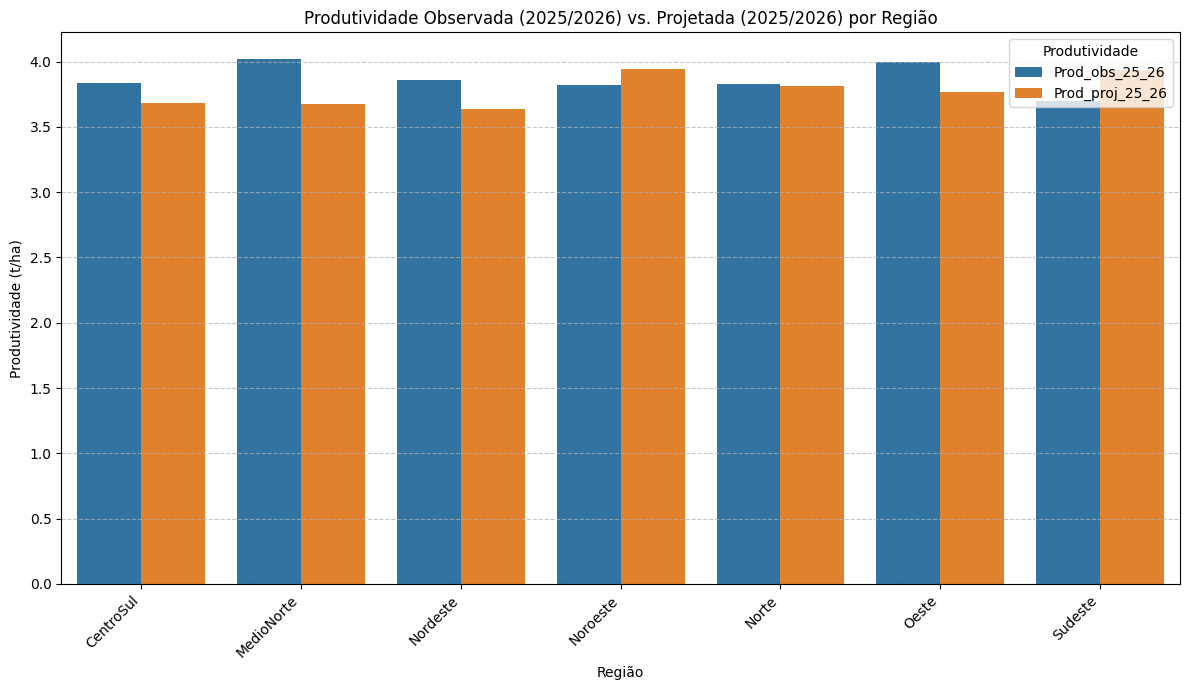

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x="Regiao", y="value", hue="variable", data=pd.melt(tabela_final, id_vars=['Regiao'], value_vars=['Prod_obs_25_26', 'Prod_proj_25_26']))
plt.title("Produtividade Observada (2025/2026) vs. Projetada (2025/2026) por Região")
plt.xlabel("Região")
plt.ylabel("Produtividade (t/ha)")
plt.legend(title="Produtividade")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

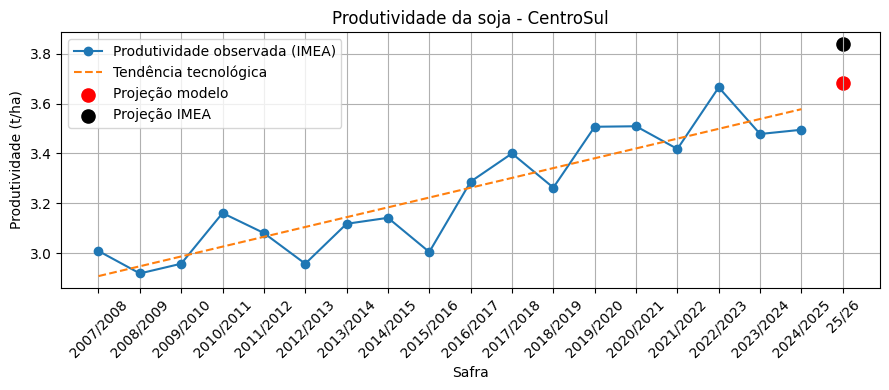

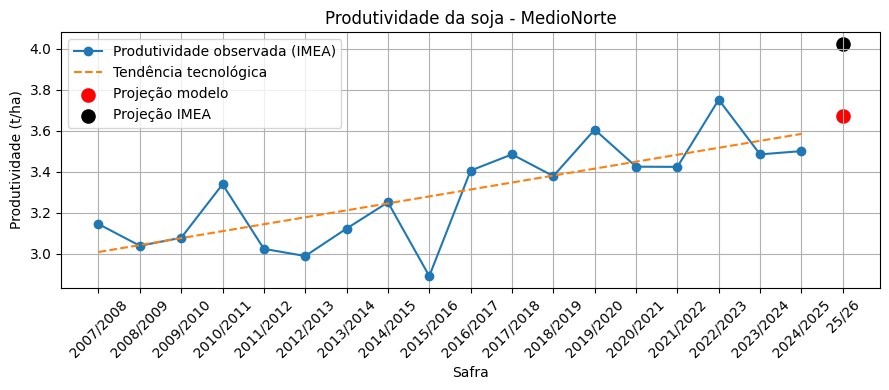

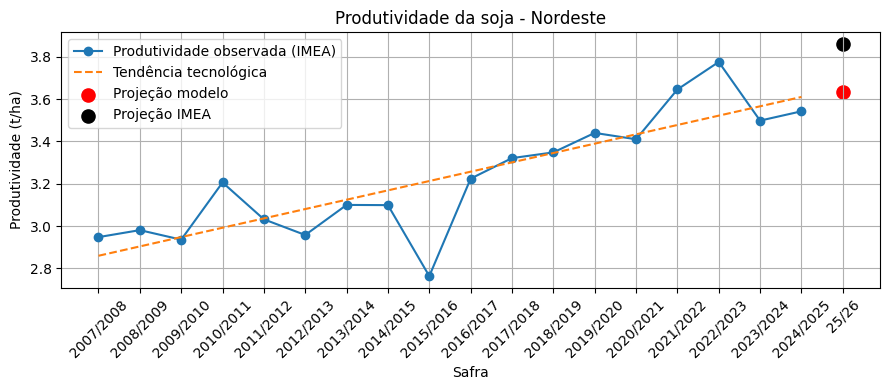

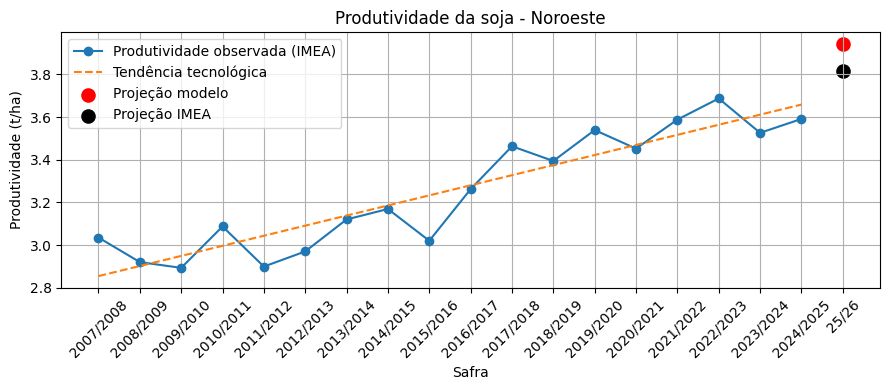

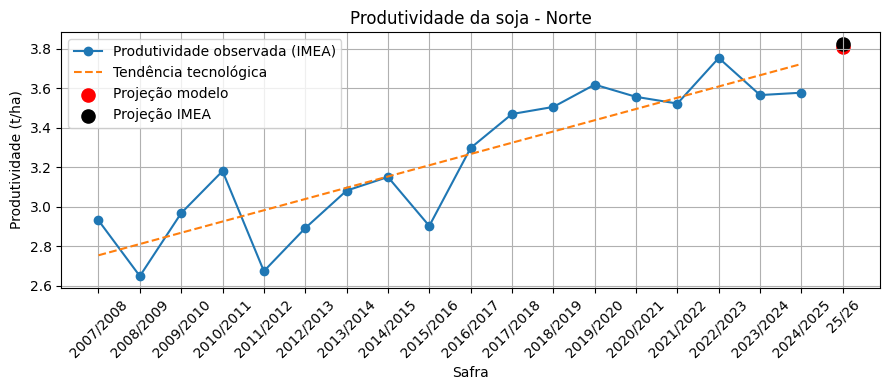

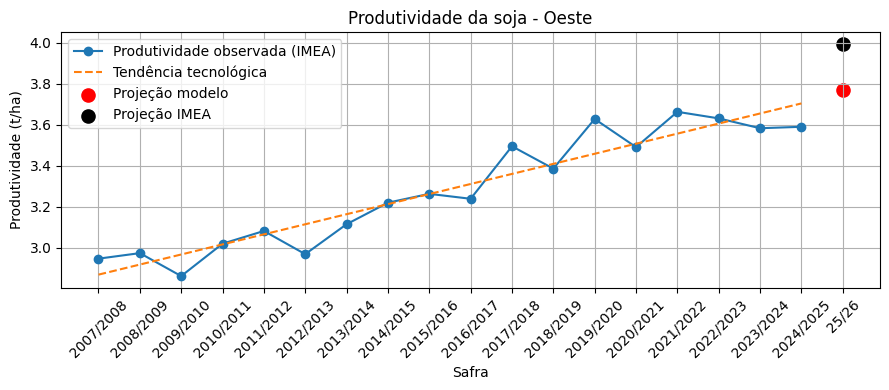

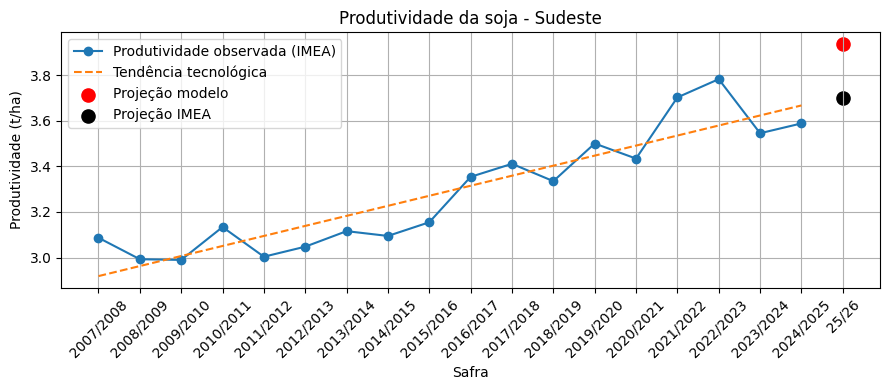

In [52]:
#gráfico por região

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

ano_proj = 2025
oni_proj = -0.6

janela_media = dataset.groupby("Regiao")["janela_plantio"].mean()
precip_media = dataset.groupby("Regiao")["precip_total"].mean()

for r in dataset["Regiao"].unique():

    sub = dataset[dataset["Regiao"] == r].copy()
    sub = sub.sort_values("ano")

    coef = resultados_df[resultados_df["Regiao"] == r].iloc[0]

    janela = janela_media[r]
    precip = precip_media[r]

    prod_proj_modelo = (
        coef["intercepto"]
        + coef["coef_ano"] * ano_proj
        + coef["coef_precip"] * precip
        + coef["coef_ONI"] * oni_proj
        + coef["coef_janela"] * janela
    )

    imea_2526 = imea[(imea["Regiao"] == r) & (imea["Safra"] == "2025/2026")]["Produtividade"].values[0]

    X = sub[["ano"]]
    y = sub["Produtividade"]

    modelo = LinearRegression()
    modelo.fit(X, y)
    sub["trend"] = modelo.predict(X)

    plt.figure(figsize=(9,4))

    # série histórica IMEA
    plt.plot(sub["Safra"], sub["Produtividade"],
             marker="o", label="Produtividade observada (IMEA)")

    # tendência tecnológica
    plt.plot(sub["Safra"], sub["trend"],
             linestyle="--", label="Tendência tecnológica")

    # projeção modelo
    plt.scatter("25/26", prod_proj_modelo,
                color="red", s=90, label="Projeção modelo")

    # projeção IMEA
    plt.scatter("25/26", imea_2526,
                color="black", s=90, label="Projeção IMEA")

    plt.title(f"Produtividade da soja - {r}")
    plt.xlabel("Safra")
    plt.ylabel("Produtividade (t/ha)")

    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [54]:
# =====================================================
# SIMULAÇÃO DE CENÁRIOS DE ONI
#tabela de produtividade projetada por cenário e região
# =====================================================

cenarios_oni = {
    "La Nina forte": -1.5,
    "La Nina fraca": -0.5,
    "Neutro": 0,
    "El Nino moderado": 1.0,
    "El Nino forte": 2.0
}

ano_proj = 2025

janela_media = dataset.groupby("Regiao")["janela_plantio"].mean()
precip_media = dataset.groupby("Regiao")["precip_total"].mean()

resultados_cenarios = []

for r in dataset["Regiao"].unique():

    coef = resultados_df[resultados_df["Regiao"] == r].iloc[0]

    janela = janela_media[r]
    precip = precip_media[r]

    for nome_cenario, oni_val in cenarios_oni.items():

        prod_proj = (
            coef["intercepto"]
            + coef["coef_ano"] * ano_proj
            + coef["coef_precip"] * precip
            + coef["coef_ONI"] * oni_val
            + coef["coef_janela"] * janela
        )

        resultados_cenarios.append({
            "Regiao": r,
            "Cenario_ONI": nome_cenario,
            "ONI": oni_val,
            "Produtividade_proj": round(prod_proj,3)
        })

df_cenarios = pd.DataFrame(resultados_cenarios)

print("\nSimulação de cenários climáticos (ONI)\n")
print(df_cenarios)


Simulação de cenários climáticos (ONI)

        Regiao       Cenario_ONI  ONI  Produtividade_proj
0    CentroSul     La Nina forte -1.5               3.731
1    CentroSul     La Nina fraca -0.5               3.678
2    CentroSul            Neutro  0.0               3.651
3    CentroSul  El Nino moderado  1.0               3.598
4    CentroSul     El Nino forte  2.0               3.544
5   MedioNorte     La Nina forte -1.5               3.683
6   MedioNorte     La Nina fraca -0.5               3.671
7   MedioNorte            Neutro  0.0               3.665
8   MedioNorte  El Nino moderado  1.0               3.653
9   MedioNorte     El Nino forte  2.0               3.640
10    Nordeste     La Nina forte -1.5               3.643
11    Nordeste     La Nina fraca -0.5               3.634
12    Nordeste            Neutro  0.0               3.629
13    Nordeste  El Nino moderado  1.0               3.620
14    Nordeste     El Nino forte  2.0               3.611
15    Noroeste     La Nina fort

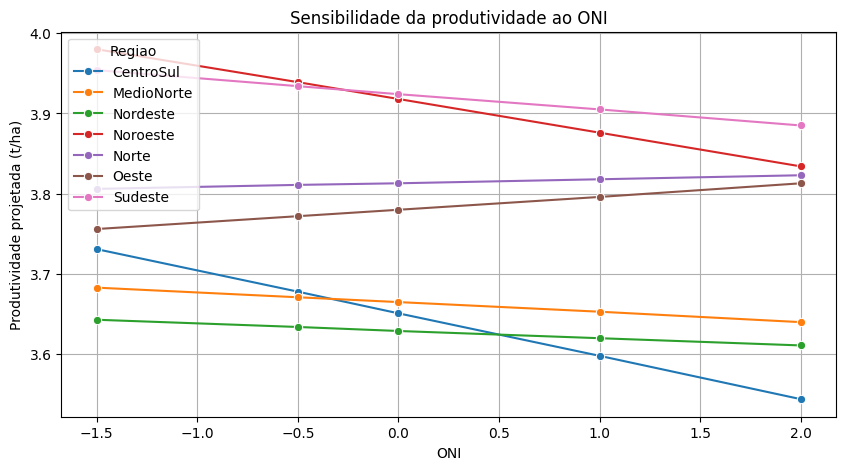

In [55]:
#gráfico de sensibilidade ao ONI
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_cenarios,
    x="ONI",
    y="Produtividade_proj",
    hue="Regiao",
    marker="o"
)

plt.title("Sensibilidade da produtividade ao ONI")
plt.xlabel("ONI")
plt.ylabel("Produtividade projetada (t/ha)")
plt.grid(True)

plt.show()

In [57]:
# ==========================================================
# TESTES ESTATÍSTICOS DO MODELO (VERSÃO CORRIGIDA)
# ==========================================================

import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson

resultados_testes = []

for r in dataset["Regiao"].unique():

    sub = dataset[dataset["Regiao"] == r].copy()

    # selecionar variáveis
    df_model = sub[["Produtividade","ano","precip_total","ONI","janela_plantio"]]

    # remover valores faltantes
    df_model = df_model.dropna()

    X = df_model[["ano","precip_total","ONI","janela_plantio"]]
    y = df_model["Produtividade"]

    X = sm.add_constant(X)

    modelo = sm.OLS(y, X).fit()

    residuos = modelo.resid

    # teste F
    p_f = modelo.f_pvalue

    # normalidade
    stat_shap, p_shap = shapiro(residuos)

    # autocorrelação
    dw = durbin_watson(residuos)

    resultados_testes.append({
        "Regiao": r,
        "R2": round(modelo.rsquared,3),
        "p_valor_F": round(p_f,4),
        "Durbin_Watson": round(dw,3),
        "Shapiro_p": round(p_shap,4),
        "Normalidade_residuos": "Sim" if p_shap > 0.05 else "Não"
    })

df_testes = pd.DataFrame(resultados_testes)

print("\n================ TESTES DO MODELO ================\n")
print(df_testes)


================ TESTES DO MODELO ================

       Regiao     R2  p_valor_F  Durbin_Watson  Shapiro_p Normalidade_residuos
0   CentroSul  0.820     0.0045          1.901     0.9559                  Sim
1  MedioNorte  0.684     0.0373          2.332     0.4111                  Sim
2    Nordeste  0.899     0.0005          1.618     0.7166                  Sim
3    Noroeste  0.926     0.0001          1.721     0.2781                  Sim
4       Norte  0.804     0.0062          1.485     0.2617                  Sim
5       Oeste  0.831     0.0036          1.723     0.3284                  Sim
6     Sudeste  0.881     0.0009          1.612     0.6898                  Sim
